<a href="https://colab.research.google.com/github/jaiswalakanksha22-glitch/Python-AI/blob/AI/Project6_Jaiswal_Akanksha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You are a data scientist in a call center. You are given a tab-delimited bilingual sentence pair contained in the file, deu-eng.txt.

The dataset has the following format:

English + TAB + German + TAB + Attribution

You are asked to develop a sequence to sequence model using RNN to translate English to German using the attached Jupyter Notebook and writing a script in Python, and running all the cells.

1. Load the data, deu-eng.txt, into memory and clean and prepare the data.

In [9]:
import os
import random
import numpy as np
import tensorflow as tf
from tensorflow import keras

# Fix the seeds
# https://stackoverflow.com/questions/1805265/how-to-fix-value-produced-by-random
SEED = 101
os.environ['PYTHONHASHSEED']=str(SEED)
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [2]:
# Upload file from local system
from google.colab import files
uploaded = files.upload()

Saving deu-eng.txt to deu-eng.txt


In [10]:
# ============================================
# English → German Translation (Seq2Seq - RNN)
# Data Loading and Preprocessing
# ============================================

# Path to dataset
data_path = "deu-eng.txt"

# Number of samples to train on
num_samples = 10000

# Lists to store input (English) and target (German) texts
input_texts = []
target_texts = []

# Sets to store unique characters
input_characters = set()
target_characters = set()

# ============================================
# Load and Process the Data
# ============================================

with open(data_path, "r", encoding="utf-8") as f:
    lines = f.read().split("\n")

for line in lines[: min(num_samples, len(lines) - 1)]:

    # Split using TAB → format: English \t German \t Attribution
    parts = line.split("\t")

    # Skip malformed lines
    if len(parts) < 2:
        continue

    # Extract input and target text
    input_text = parts[0].lower().strip()
    target_text = parts[1].lower().strip()

    # Add start (\t) and end (\n) tokens to target
    target_text = "\t" + target_text + "\n"

    # Store processed texts
    input_texts.append(input_text)
    target_texts.append(target_text)

    # Collect unique characters from input
    for char in input_text:
        if char not in input_characters:
            input_characters.add(char)

    # Collect unique characters from target
    for char in target_text:
        if char not in target_characters:
            target_characters.add(char)

# ============================================
# Sort and Calculate Statistics
# ============================================

input_characters = sorted(list(input_characters))
target_characters = sorted(list(target_characters))

# Vocabulary sizes
num_encoder_tokens = len(input_characters)
num_decoder_tokens = len(target_characters)

# Maximum sequence lengths
max_encoder_seq_length = max([len(txt) for txt in input_texts])
max_decoder_seq_length = max([len(txt) for txt in target_texts])

# ============================================
# Display Dataset Information
# ============================================

print("Number of samples:", len(input_texts))
print("Number of unique input tokens:", num_encoder_tokens)
print("Number of unique output tokens:", num_decoder_tokens)
print("Max sequence length for inputs:", max_encoder_seq_length)
print("Max sequence length for outputs:", max_decoder_seq_length)

Number of samples: 10000
Number of unique input tokens: 47
Number of unique output tokens: 57
Max sequence length for inputs: 15
Max sequence length for outputs: 45


In [13]:

input_token_index = {char: i for i, char in enumerate(input_characters)}
target_token_index = {char: i for i, char in enumerate(target_characters)}
# Initialize the 3 D matrix
encoder_input_data = np.zeros(
    (len(input_texts), max_encoder_seq_length, num_encoder_tokens), dtype="float32"
)
decoder_input_data = np.zeros(
    (len(target_texts), max_decoder_seq_length, num_decoder_tokens), dtype="float32"
)
decoder_target_data = np.zeros(
    (len(target_texts), max_decoder_seq_length, num_decoder_tokens), dtype="float32"
)

# Convert the input texts and target texts to numerical values
for i, (input_text, target_text) in enumerate(zip(input_texts, target_texts)):
    # Convert input texts to numerical values
    for t, char in enumerate(input_text):
        encoder_input_data[i, t, input_token_index[char]] = 1.0
    # Pad the remaining using space that is mapped to 1

    encoder_input_data[i, t + 1 :, input_token_index[" "]] = 1.0
    # Convert target texts to numerical values
    for t, char in enumerate(target_text):
        # decoder input is used to forecast decoder target
        # decoder_target_data is ahead of decoder_input_data by one timestep
        decoder_input_data[i, t, target_token_index[char]] = 1.0
        if t > 0:
            # decoder_target_data will be ahead by one timestep
            # and will not include the start character.
            decoder_target_data[i, t - 1, target_token_index[char]] = 1.0
    # Pad the remaining using space that is mapped to 1
    decoder_input_data[i, t + 1 :, target_token_index[" "]] = 1.0
    decoder_target_data[i, t:, target_token_index[" "]] = 1.0
encoder_input_data



array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

In [14]:
decoder_input_data


array([[[1., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 1., ..., 0., 0., 0.],
        [0., 0., 1., ..., 0., 0., 0.],
        [0., 0., 1., ..., 0., 0., 0.]],

       [[1., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 1., ..., 0., 0., 0.],
        [0., 0., 1., ..., 0., 0., 0.],
        [0., 0., 1., ..., 0., 0., 0.]],

       [[1., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 1., ..., 0., 0., 0.],
        [0., 0., 1., ..., 0., 0., 0.],
        [0., 0., 1., ..., 0., 0., 0.]],

       ...,

       [[1., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 1., ..., 0., 0., 0.],
        [0., 0., 1., ..., 0., 0., 0.],
        [0., 0., 1., ..., 0., 0.

In [15]:
decoder_target_data

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 1., ..., 0., 0., 0.],
        [0., 0., 1., ..., 0., 0., 0.],
        [0., 0., 1., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 1., ..., 0., 0., 0.],
        [0., 0., 1., ..., 0., 0., 0.],
        [0., 0., 1., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 1., ..., 0., 0., 0.],
        [0., 0., 1., ..., 0., 0., 0.],
        [0., 0., 1., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 1., ..., 0., 0., 0.],
        [0., 0., 1., ..., 0., 0., 0.],
        [0., 0., 1., ..., 0., 0.

2. Develop an encoder for the model.


In [16]:
# ============================================
# Seq2Seq Model: Encoder–Decoder Architecture
# ============================================

from tensorflow import keras

# Latent dimension for LSTM
latent_dim = 256

# ============================================
#  Encoder
# ============================================

# Define encoder input
encoder_inputs = keras.Input(shape=(None, num_encoder_tokens), name="encoder_inputs")

# LSTM layer (returns hidden states)
encoder_lstm = keras.layers.LSTM(latent_dim, return_state=True, name="encoder_lstm")

# Get encoder outputs and states
encoder_outputs, state_h, state_c = encoder_lstm(encoder_inputs)

# Keep only states (context vector)
encoder_states = [state_h, state_c]



3. Develop a decoder for the model.

In [17]:
# ============================================
#  Decoder
# ============================================

# Define decoder input
decoder_inputs = keras.Input(shape=(None, num_decoder_tokens), name="decoder_inputs")

# Decoder LSTM
decoder_lstm = keras.layers.LSTM(
    latent_dim,
    return_sequences=True,
    return_state=True,
    name="decoder_lstm"
)

# Use encoder states as initial state
decoder_outputs, _, _ = decoder_lstm(
    decoder_inputs,
    initial_state=encoder_states
)

# Dense layer to predict next character
decoder_dense = keras.layers.Dense(
    num_decoder_tokens,
    activation="softmax",
    name="decoder_dense"
)

decoder_outputs = decoder_dense(decoder_outputs)


4. Build the sequence to sequence model.

In [18]:

# ============================================
# 🔗 Define Full Model
# ============================================

model = keras.Model(
    [encoder_inputs, decoder_inputs],
    decoder_outputs
)

# ============================================
# Compile Model
# ============================================

model.compile(
    optimizer="rmsprop",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Display model summary
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_inputs      │ (None, None, 47)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_inputs      │ (None, None, 57)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 256),     │    311,296 │ encoder_inputs[0… │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, None,     │    321,536 │ decoder_inputs[0… │
│                     │ 256), (None,      │            │ encoder_lstm[0][… │
│                     │ 256), (None,      │            │ encoder_lstm[0][… │
│                     │ 256)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dense       │ (None, None, 57)  │     14,649 │ decoder_lstm[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 647,481 (2.47 MB)

 Trainable params: 647,481 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

5. Train the model.

In [21]:
from tensorflow.keras.callbacks import EarlyStopping

# Training parameters
batch_size = 64
epochs = 20

# Early stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    min_delta=0.001,
    mode='min',
    restore_best_weights=True
)

# Train the model
history = model.fit(
    [encoder_input_data, decoder_input_data],
    decoder_target_data,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.2,
    callbacks=[early_stopping],
)

# Save the trained model
model.save("s2s_model.keras")

Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 39s 314ms/step - accuracy: 0.8535 - loss: 0.4941 - val_accuracy: 0.8174 - val_loss: 0.6258
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 43s 345ms/step - accuracy: 0.8559 - loss: 0.4858 - val_accuracy: 0.8191 - val_loss: 0.6190
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 44s 353ms/step - accuracy: 0.8587 - loss: 0.4772 - val_accuracy: 0.8198 - val_loss: 0.6162
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 81s 344ms/step - accuracy: 0.8607 - loss: 0.4698 - val_accuracy: 0.8217 - val_loss: 0.6105
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 45s 358ms/step - accuracy: 0.8633 - loss: 0.4616 - val_accuracy: 0.8225 - val_loss: 0.6095
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 42s 335ms/step - accuracy: 0.8655 - loss: 0.4544 - val_accuracy: 0.8234 - val_loss: 0.6051
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 42s 330ms/step - accuracy: 0.8676 - loss: 0.4473 - val_accuracy: 0.8238 - val_loss: 0.6058
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 41s 326ms/step - accuracy: 0.8698 - loss: 0

6. Evaluate the model and check the model fit.

In [23]:
# Evaluate Model on Validation Data
print("Final Training Loss:", history.history['loss'][-1])
print("Final Validation Loss:", history.history['val_loss'][-1])

print("Final Training Accuracy:", history.history['accuracy'][-1])
print("Final Validation Accuracy:", history.history['val_accuracy'][-1])

Final Training Loss: 0.3685760200023651
Final Validation Loss: 0.5981925129890442
Final Training Accuracy: 0.8909082412719727
Final Validation Accuracy: 0.8298444747924805


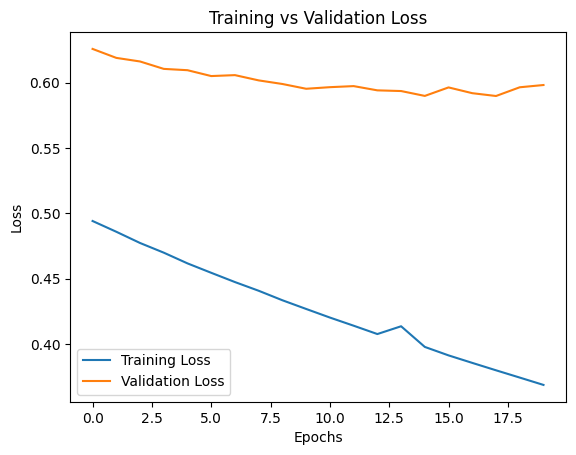

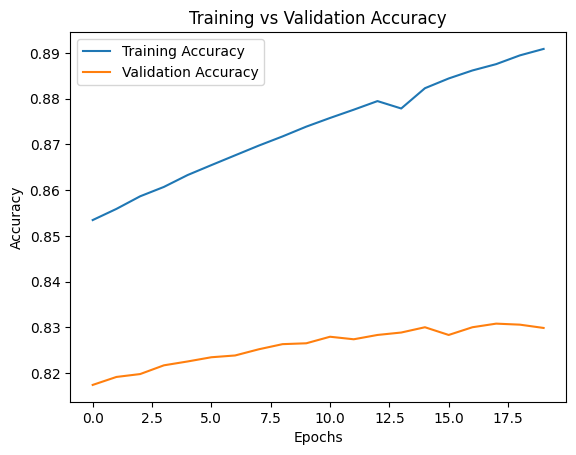

In [24]:
# Plot Model Performance
import matplotlib.pyplot as plt

# Loss Plot
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Accuracy Plot
plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

The model shows a consistent decrease in training loss and an increase in training accuracy, indicating effective learning on the training data. However, the validation loss remains relatively high and does not decrease significantly, while validation accuracy plateaus after a few epochs. This indicates moderate overfitting, where the model performs better on training data than on unseen data. Early stopping helped prevent severe overfitting, but further improvements such as regularization or more data may enhance generalization.

7. Run the inference.

In [25]:
# Build Inference Models

# Encoder model (returns states)
encoder_model = keras.Model(encoder_inputs, encoder_states)

In [26]:
# Define new input layers for decoder states
decoder_state_input_h = keras.Input(shape=(latent_dim,))
decoder_state_input_c = keras.Input(shape=(latent_dim,))
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

# Reuse decoder LSTM
decoder_outputs, state_h, state_c = decoder_lstm(
    decoder_inputs,
    initial_state=decoder_states_inputs
)

decoder_states = [state_h, state_c]

# Reuse dense layer
decoder_outputs = decoder_dense(decoder_outputs)

# Final decoder model
decoder_model = keras.Model(
    [decoder_inputs] + decoder_states_inputs,
    [decoder_outputs] + decoder_states
)

In [29]:
# Reverse Token Index
reverse_input_char_index = dict((i, char) for char, i in input_token_index.items())
reverse_target_char_index = dict((i, char) for char, i in target_token_index.items())

In [30]:

# Decode Function (Core Translation Logic)

def decode_sequence(input_seq):
    # Encode input → get states
    states_value = encoder_model.predict(input_seq)

    # Start token
    target_seq = np.zeros((1, 1, num_decoder_tokens))
    target_seq[0, 0, target_token_index["\t"]] = 1.0

    stop_condition = False
    decoded_sentence = ""

    while not stop_condition:
        output_tokens, h, c = decoder_model.predict(
            [target_seq] + states_value
        )

        # Get predicted character
        sampled_token_index = np.argmax(output_tokens[0, -1, :])
        sampled_char = reverse_target_char_index[sampled_token_index]
        decoded_sentence += sampled_char

        # Stop condition
        if (sampled_char == "\n" or len(decoded_sentence) > max_decoder_seq_length):
            stop_condition = True

        # Update target sequence
        target_seq = np.zeros((1, 1, num_decoder_tokens))
        target_seq[0, 0, sampled_token_index] = 1.0

        # Update states
        states_value = [h, c]

    return decoded_sentence

In [31]:
# Test Translations
for seq_index in range(10):
    input_seq = encoder_input_data[seq_index: seq_index + 1]

    decoded_sentence = decode_sequence(input_seq)

    print("English:", input_texts[seq_index])
    print("German:", decoded_sentence)
    print("-" * 40)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
English: go.
German: versuchen sie tom!

----------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 

The trained Seq2Seq model was used to generate German translations from English input sentences using an inference mechanism. The decoder predicts one character at a time until the end-of-sequence token is reached.